Processing model directory: ../data/bool_q/llama2(3)+llama3(3)
Error processing task directory ../data/bool_q/llama2(3)+llama3(3)/4780: Answer not recognized
Error processing task directory ../data/bool_q/llama2(3)+llama3(3)/7627: Answer not recognized
Error processing task directory ../data/bool_q/llama2(3)+llama3(3)/767: Answer not recognized


Processing llama2(3)+llama3(3): 100%|██████████| 2000/2000 [00:00<00:00, 8321.13it/s]


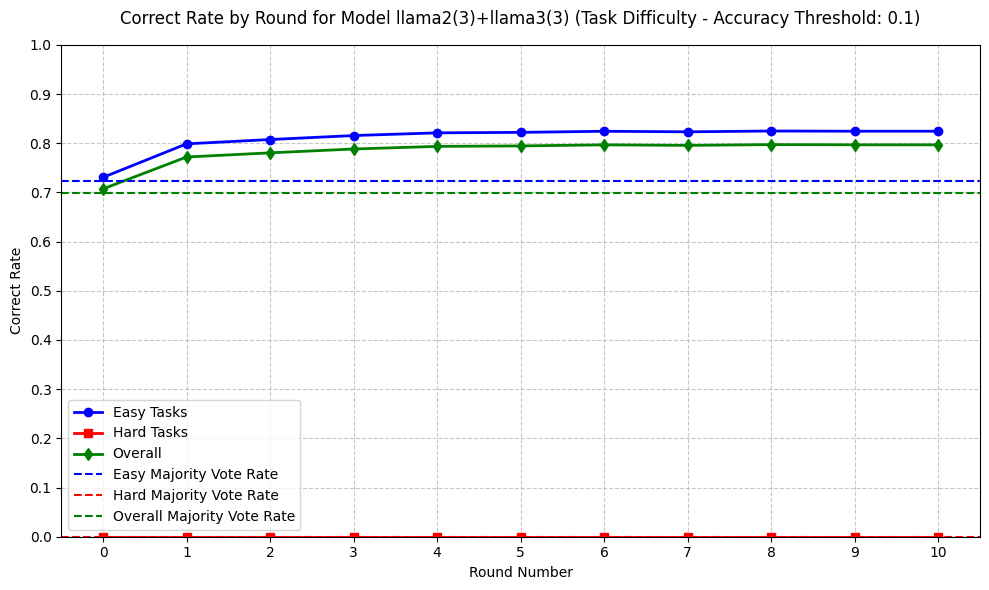

Processing model directory: ../data/bool_q/llama3(3)
Error processing task directory ../data/bool_q/llama3(3)/7913: Answer not recognized


Processing llama3(3): 100%|██████████| 2000/2000 [00:00<00:00, 7302.49it/s]


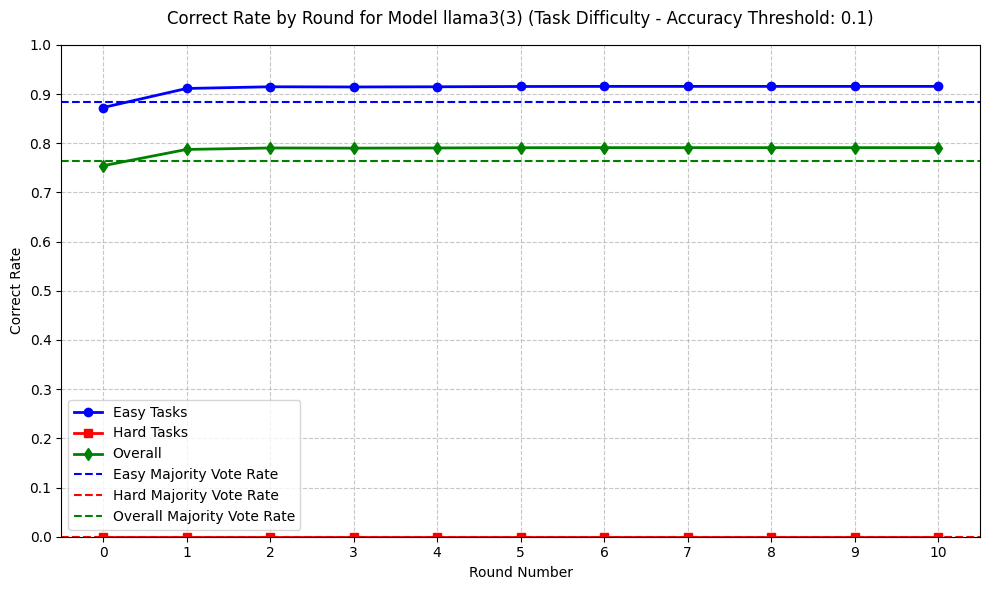

Processing model directory: ../data/bool_q/llama2(1)+llama3(1)+mistral(1)
Error processing task directory ../data/bool_q/llama2(1)+llama3(1)+mistral(1)/1146: Answer not recognized
Error processing task directory ../data/bool_q/llama2(1)+llama3(1)+mistral(1)/3317: Answer not recognized


Processing llama2(1)+llama3(1)+mistral(1): 100%|██████████| 2000/2000 [00:00<00:00, 8191.42it/s]


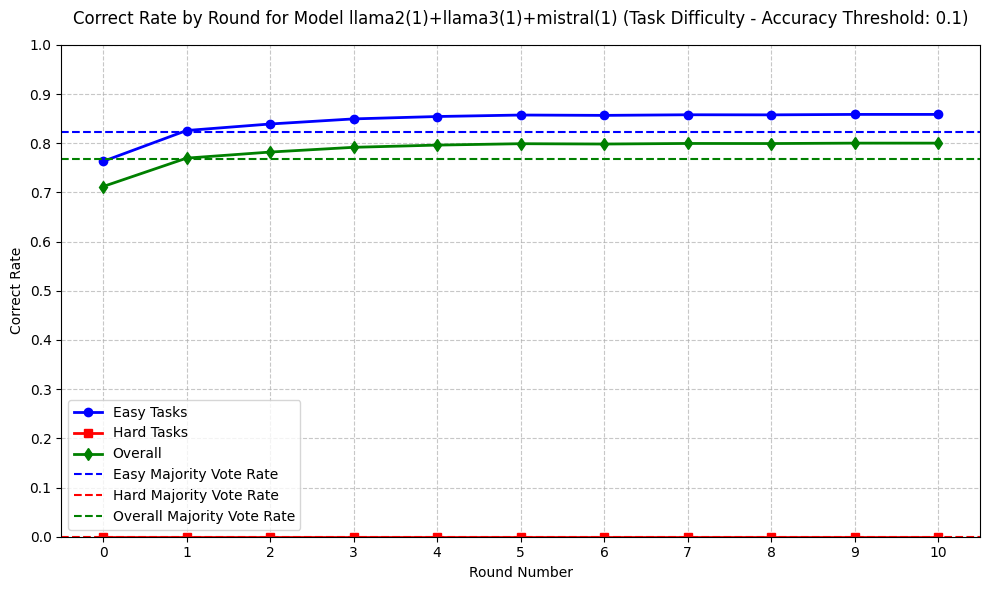

Processing model directory: ../data/bool_q/llama2(3)
Error processing task directory ../data/bool_q/llama2(3)/1196: Answer not recognized
Error processing task directory ../data/bool_q/llama2(3)/2877: Answer not recognized
Error processing task directory ../data/bool_q/llama2(3)/4337: Answer not recognized
Error processing task directory ../data/bool_q/llama2(3)/5826: Answer not recognized


Processing llama2(3): 100%|██████████| 2000/2000 [00:00<00:00, 7301.43it/s]


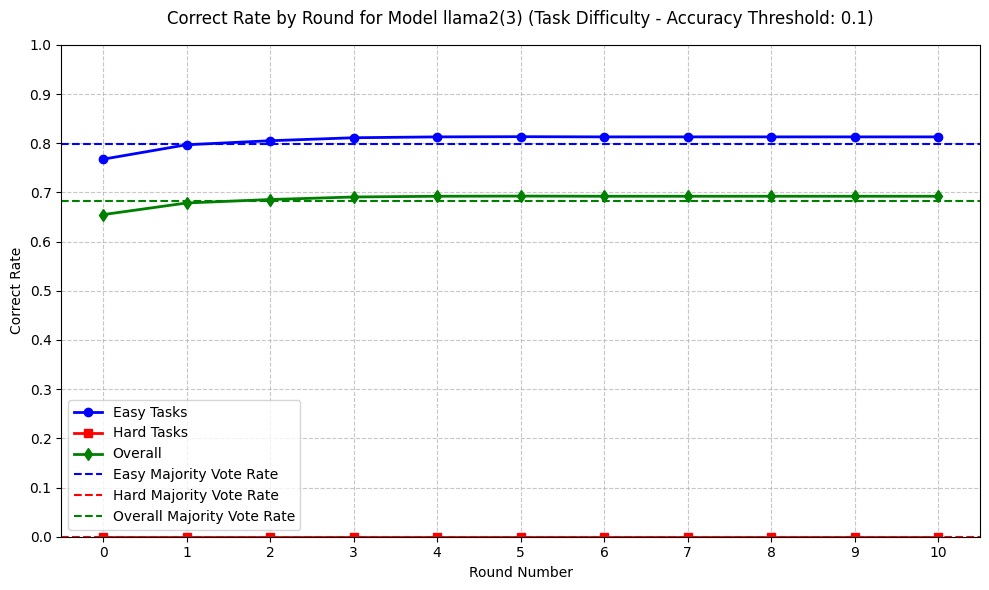

Processing model directory: ../data/bool_q/llama3(3)+mistral(3)
Error processing task directory ../data/bool_q/llama3(3)+mistral(3)/3820: Answer not recognized


Processing llama3(3)+mistral(3): 100%|██████████| 2000/2000 [00:00<00:00, 8139.41it/s]


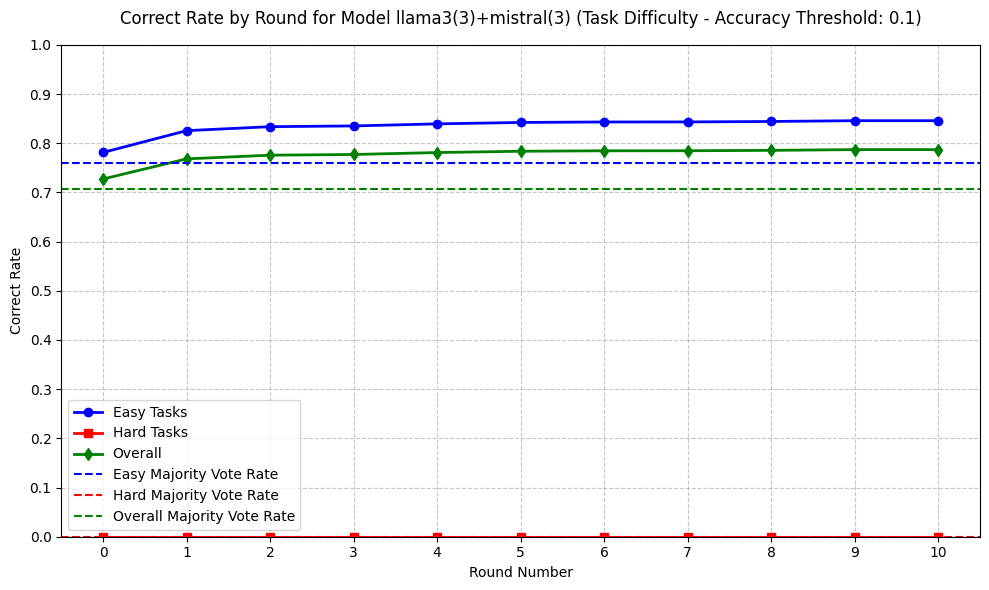

Processing model directory: ../data/bool_q/llama2(3)+mistral(3)
Error processing task directory ../data/bool_q/llama2(3)+mistral(3)/5838: Answer not recognized
Error processing task directory ../data/bool_q/llama2(3)+mistral(3)/2877: Answer not recognized
Error processing task directory ../data/bool_q/llama2(3)+mistral(3)/4013: Answer not recognized
Error processing task directory ../data/bool_q/llama2(3)+mistral(3)/7745: Answer not recognized


Processing llama2(3)+mistral(3): 100%|██████████| 2000/2000 [00:00<00:00, 8700.20it/s]


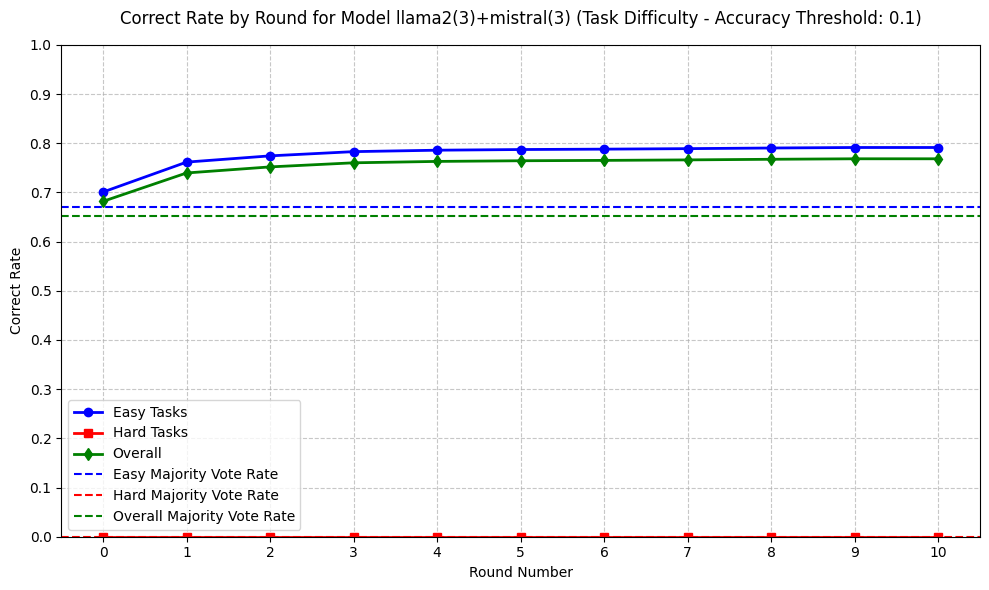

Processing model directory: ../data/bool_q/mistral(3)


Processing mistral(3): 100%|██████████| 2000/2000 [00:00<00:00, 7193.10it/s]


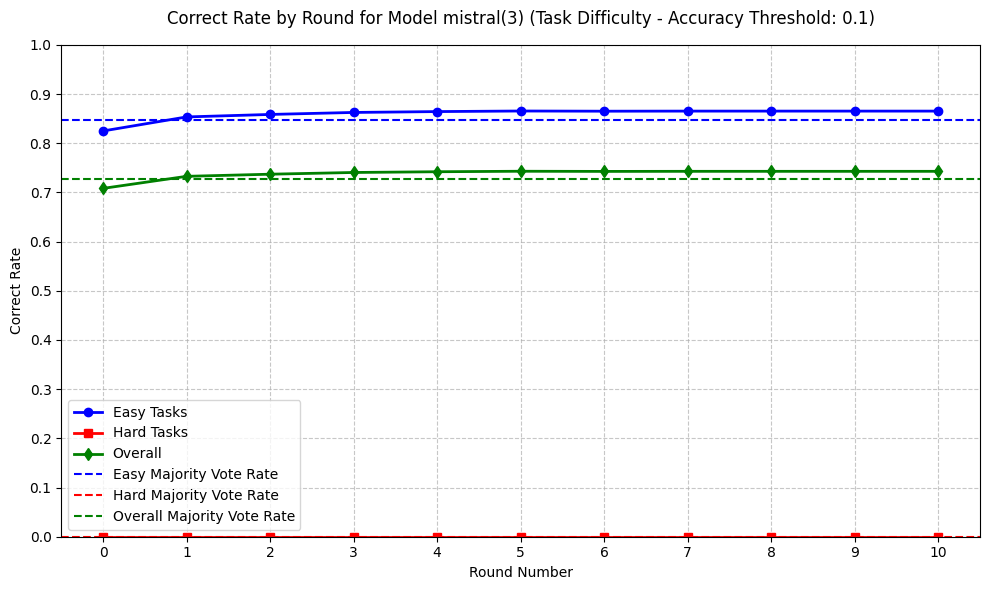

Processing model directory: ../data/bool_q/llama3(6)
Error processing task directory ../data/bool_q/llama3(6)/4044: Answer not recognized
Error processing task directory ../data/bool_q/llama3(6)/8754: Answer not recognized
Error processing task directory ../data/bool_q/llama3(6)/1938: Answer not recognized
Error processing task directory ../data/bool_q/llama3(6)/320: Answer not recognized


Processing llama3(6): 100%|██████████| 2000/2000 [00:00<00:00, 8042.78it/s]


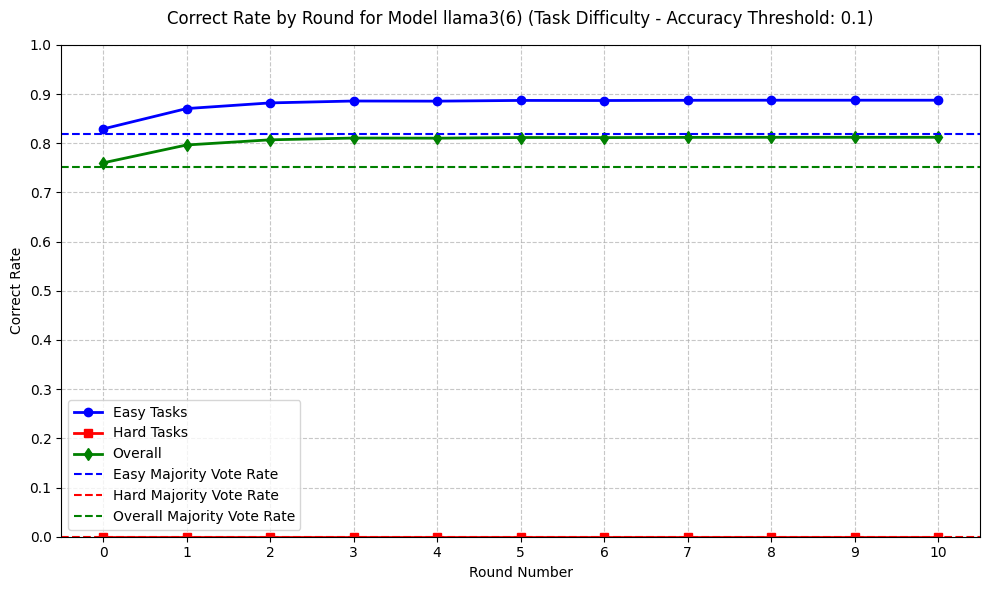

Processing model directory: ../data/bool_q/results.csv


NotADirectoryError: [Errno 20] Not a directory: '../data/bool_q/results.csv'

In [2]:
from multi_llm_debate.analysis.correct_rate_by_round import (
    calculate_correct_rate_by_round,
    calculate_majority_vote_correct_rate
)
from multi_llm_debate.analysis.classify_task_difficulty import (
    analyze_task_difficulty,
)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data path
data_path = Path("../output/bool_q/processed_data.csv")

# Load dataset
dataframe = pd.read_csv(data_path)

# Get all model directories from the specified path
model_dirs = list(Path("../data/bool_q").glob('*'))  # Convert generator to list to avoid re-evaluating it

# Define the accuracy threshold to be used
accuracy_threshold = 0.1

# Function to process each model directory
def process_model(model_dir):
    print(f"Processing model directory: {model_dir}")
    
    # Analyze task difficulty with the specified accuracy threshold
    result_df = analyze_task_difficulty(
        model_dir=model_dir,
        dataframe=dataframe,
        accuracy_threshold=accuracy_threshold,
    )

    # Filter for easy and hard tasks
    easy_df = result_df[result_df["difficulty"] == 0]
    hard_df = result_df[result_df["difficulty"] == 1]
    
    # Calculate correct rates for all tasks and for easy/hard separately
    overall_correct_rate_df = calculate_correct_rate_by_round(
        dataframe=result_df,
        model_dir=model_dir,
        max_round_number=10
    )
    
    easy_correct_rate_by_round_df = calculate_correct_rate_by_round(
        dataframe=easy_df,
        model_dir=model_dir,
        max_round_number=10
    )
    
    hard_correct_rate_by_round_df = calculate_correct_rate_by_round(
        dataframe=hard_df,
        model_dir=model_dir,
        max_round_number=10
    )

    # Get correct rates (absolute values) for easy, hard, and overall tasks
    easy_rates = easy_correct_rate_by_round_df[
        easy_correct_rate_by_round_df['metric'] == 'absolute'
    ].iloc[0, 2:].values
    hard_rates = hard_correct_rate_by_round_df[
        hard_correct_rate_by_round_df['metric'] == 'absolute'
    ].iloc[0, 2:].values
    overall_rates = overall_correct_rate_df[
        overall_correct_rate_df['metric'] == 'absolute'
    ].iloc[0, 2:].values
    
    # Calculate majority vote rates
    easy_majority_vote_rate = calculate_majority_vote_correct_rate(
        dataframe=easy_df,
        model_dir=model_dir,
    )
    hard_majority_vote_rate = calculate_majority_vote_correct_rate(
        dataframe=hard_df,
        model_dir=model_dir,
    )
    overall_majority_vote_rate = calculate_majority_vote_correct_rate(
        dataframe=dataframe,
        model_dir=model_dir,
    )
    
    # Create plot for each model
    create_plot(easy_rates, hard_rates, overall_rates, easy_majority_vote_rate, 
                hard_majority_vote_rate, overall_majority_vote_rate, model_dir)

# Function to create and save the plot
def create_plot(easy_rates, hard_rates, overall_rates, easy_majority_vote_rate, 
                hard_majority_vote_rate, overall_majority_vote_rate, model_dir):
    rounds = range(len(easy_rates))
    
    # Create figure and axis for plotting
    plt.figure(figsize=(10, 6))

    # Plot correct rate lines
    plt.plot(rounds, easy_rates, 'b-o', label='Easy Tasks', linewidth=2)
    plt.plot(rounds, hard_rates, 'r-s', label='Hard Tasks', linewidth=2)
    plt.plot(rounds, overall_rates, 'g-d', label='Overall', linewidth=2)

    # Add horizontal lines for majority vote rates
    plt.axhline(y=easy_majority_vote_rate, color='blue', linestyle='--', label='Easy Majority Vote Rate')
    plt.axhline(y=hard_majority_vote_rate, color='red', linestyle='--', label='Hard Majority Vote Rate')
    plt.axhline(y=overall_majority_vote_rate, color='green', linestyle='--', label='Overall Majority Vote Rate')

    # Customize plot with updated title
    plt.title(f'Correct Rate by Round for Model {model_dir.name} (Task Difficulty - Accuracy Threshold: {accuracy_threshold})', pad=15)
    plt.xlabel('Round Number')
    plt.ylabel('Correct Rate')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # Set y-axis limits and ticks
    plt.ylim(0, 1)
    plt.yticks(np.arange(0, 1.1, 0.1))

    # Set x-axis ticks
    plt.xticks(rounds)

    # Save plot to a file
    # plot_filename = f"{model_dir.name}_correct_rate_plot.png"
    plt.tight_layout()
    # plt.savefig(plot_filename)  # Save plot as a PNG file
    plt.show()  # Display the plot

# Sequential processing for each model
for model_dir in model_dirs:
    process_model(model_dir)  # Process each model directory in sequence
